# Phase Fractions and Phase Compositions vs Temperature

A common CALPHAD workflow is to take a single alloy composition and look at how the equilibrium phase fractions and compositions evolve with temperature.

This example uses [the open-source MatCalc Fe-Cr-Ni database](https://www.matcalc.at/index.php/databases/open-databases) to compute, for an Fe-18Cr-8Ni stainless steel composition (mass fractions):

1. The molar phase fractions `NP(<phase>)` as a function of temperature.
2. The mole-fraction composition of the sigma phase `X(SIGMA, <element>)` as a function of temperature.

It also shows how to convert between mass and mole fractions using `pycalphad.variables.get_mole_fractions`.


In [5]:
import warnings
import matplotlib.pyplot as plt
import numpy as np

from pycalphad import Database, Workspace, variables as v

# This database emits a benign warning at load about extra type-definition
# characters; it has no effect on results.
warnings.filterwarnings('ignore', category=UserWarning, module='pycalphad.io.tdb')

Load the database and translate the mass-fraction conditions `W(CR) = 0.18, W(NI) = 0.08` (with Fe as the dependent component) into the mole-fraction conditions that the Workspace expects.

In [6]:
dbf = Database('../databases/mc_fe_v2.059.pycalphad.tdb')
components = ['NI', 'CR', 'FE', 'VA']

# GP_MAT is a model phase that should not appear in an equilibrium calculation
phases = sorted(set(dbf.phases.keys()) - {'GP_MAT'})

mass_fracs = {v.W('CR'): 0.18, v.W('NI'): 0.08}
conditions = v.get_mole_fractions(mass_fracs, 'FE', dbf)
conditions[v.T] = (700, 1300, 10)
conditions[v.P] = 1e5
conditions[v.N] = 1

wks = Workspace(dbf, components, phases, conditions)
conditions

{X_CR: 0.19152036799248282,
 X_NI: 0.07541162078822543,
 T: (700, 1300, 10),
 P: 100000.0,
 N: 1}

## Phase fractions vs temperature

Use `wks.get_dict("NP(*)")` to retrieve molar fractions for every phase. Filter out phases that never reach a meaningful fraction so only the stable phases are plotted.

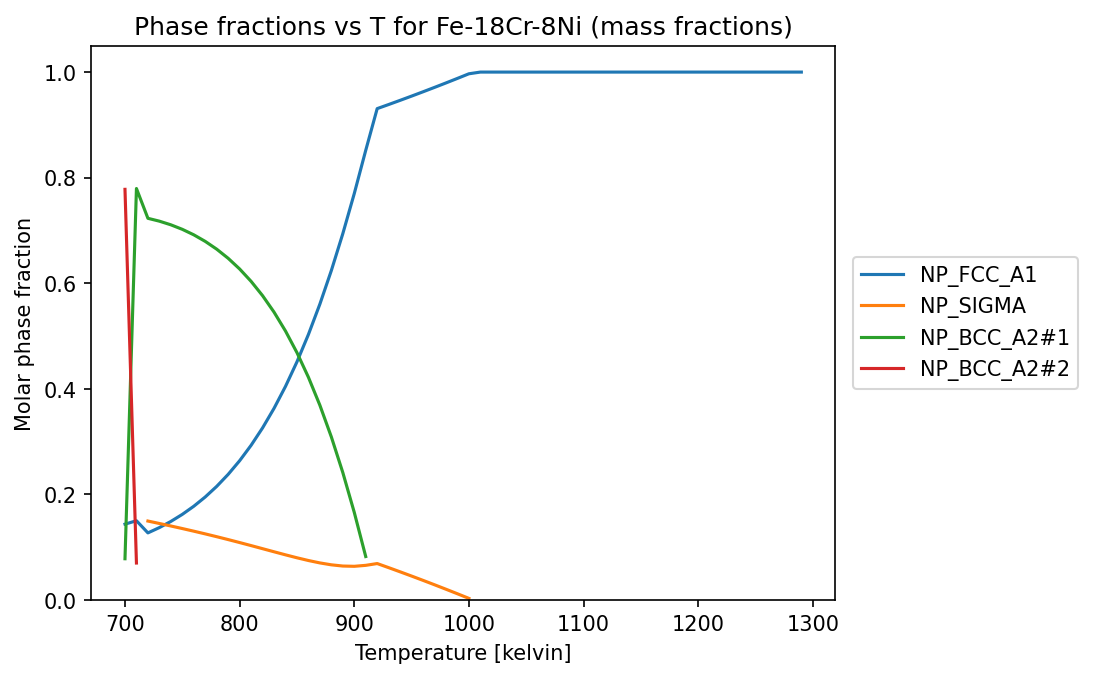

In [7]:
T = wks.get(v.T)
np_dict = wks.get_dict('NP(*)')

fig, ax = plt.subplots(dpi=150)
for prop, values in np_dict.items():
    arr = np.asarray(values)
    if not np.any(np.isfinite(arr) & (arr > 1e-6)):
        continue
    ax.plot(T, arr, label=str(prop))

ax.set_title('Phase fractions vs T for Fe-18Cr-8Ni (mass fractions)')
ax.set_xlabel(f'{v.T.display_name} [{v.T.display_units}]')
ax.set_ylabel('Molar phase fraction')
ax.set_ylim(0, 1.05)
ax.legend(loc='center left', bbox_to_anchor=(1.01, 0.5))

## SIGMA phase composition vs temperature

For a single phase, `wks.get(v.X(phase, element))` returns the per-phase mole fraction of each element across the temperature sweep. Values are `NaN` where the phase is not stable.

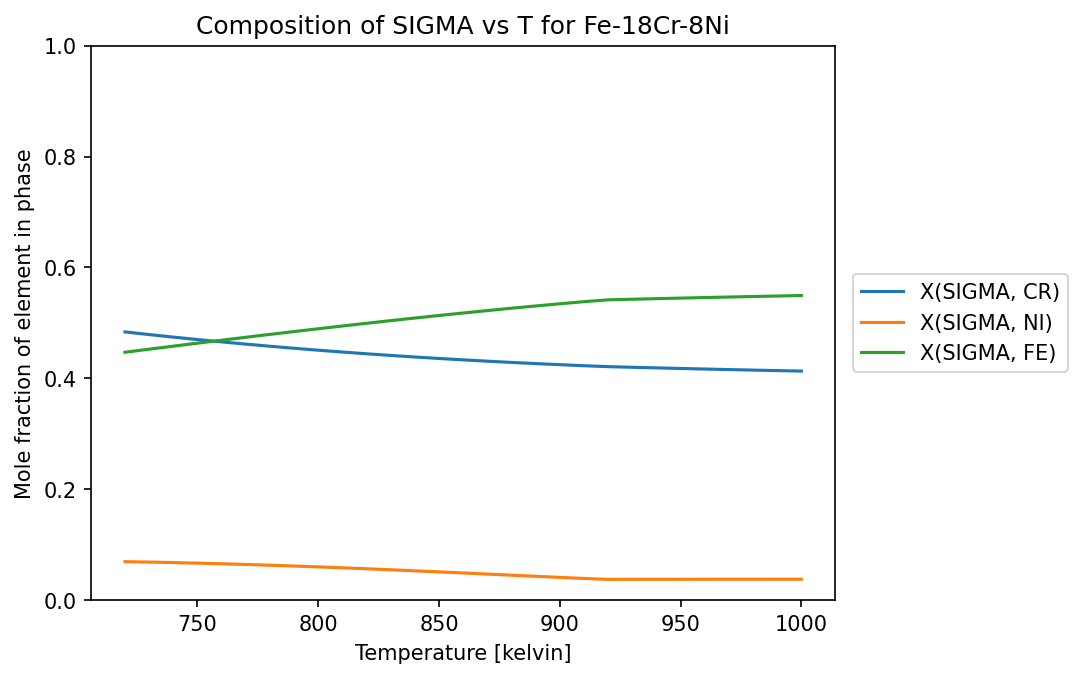

In [8]:
desired_phase = 'SIGMA'
elements = ['CR', 'NI', 'FE']

fig, ax = plt.subplots(dpi=150)
for el in elements:
    ax.plot(T, wks.get(v.X(desired_phase, el)), label=f"X({desired_phase}, {el})")

ax.set_title(f'Composition of {desired_phase} vs T for Fe-18Cr-8Ni')
ax.set_xlabel(f'{v.T.display_name} [{v.T.display_units}]')
ax.set_ylabel('Mole fraction of element in phase')
ax.set_ylim(0, 1.0)
ax.legend(loc='center left', bbox_to_anchor=(1.01, 0.5))